# Printing Research project/internship
This is the code for finding an appropriate learning algorithm for the printing project "" <br>
People working on it : Neevan Redkar, Aryan Parihar, Avyay Joshi, Pranav Ijantkar

We first import all required libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV,LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('New and better synthetic data.xlsx')
df

,Press ID,Paper type,Zone number,Color,Ink key zero setting,Delta E before,Delta E after,initial density,final density,initial ink key setting,final ink key setting,Ink Key Difference (%)
0,1,Uncoated,1,Cyan,0mm,19.8,2.0,0.879,0.729,90.440,80.540,9.900
1,1,Uncoated,2,Cyan,0mm,19.8,2.0,1.128,0.484,81.000,38.496,42.504
2,1,Uncoated,3,Cyan,0mm,19.8,2.0,1.467,0.270,80.550,1.548,79.002
3,1,Uncoated,4,Cyan,0mm,19.8,2.0,0.962,0.186,66.025,14.809,51.216
4,1,Uncoated,5,Cyan,0mm,19.8,2.0,0.867,0.465,88.928,62.396,26.532
...,...,...,...,...,...,...,...,...,...,...,...,...
2195,1,Uncoated,18,Black,0mm,11.9,2.0,1.466,0.243,90.000,9.282,80.718
2196,1,Uncoated,19,Black,0mm,11.9,2.0,1.204,0.454,65.112,15.612,49.500
2197,1,Uncoated,20,Black,0mm,11.9,2.0,0.906,0.761,94.148,84.578,9.570
2198,1,Uncoated,21,Black,0mm,11.9,2.0,0.998,0.128,95.365,37.945,57.420


After reading the Dataset, we perform exploratory data analysis on it

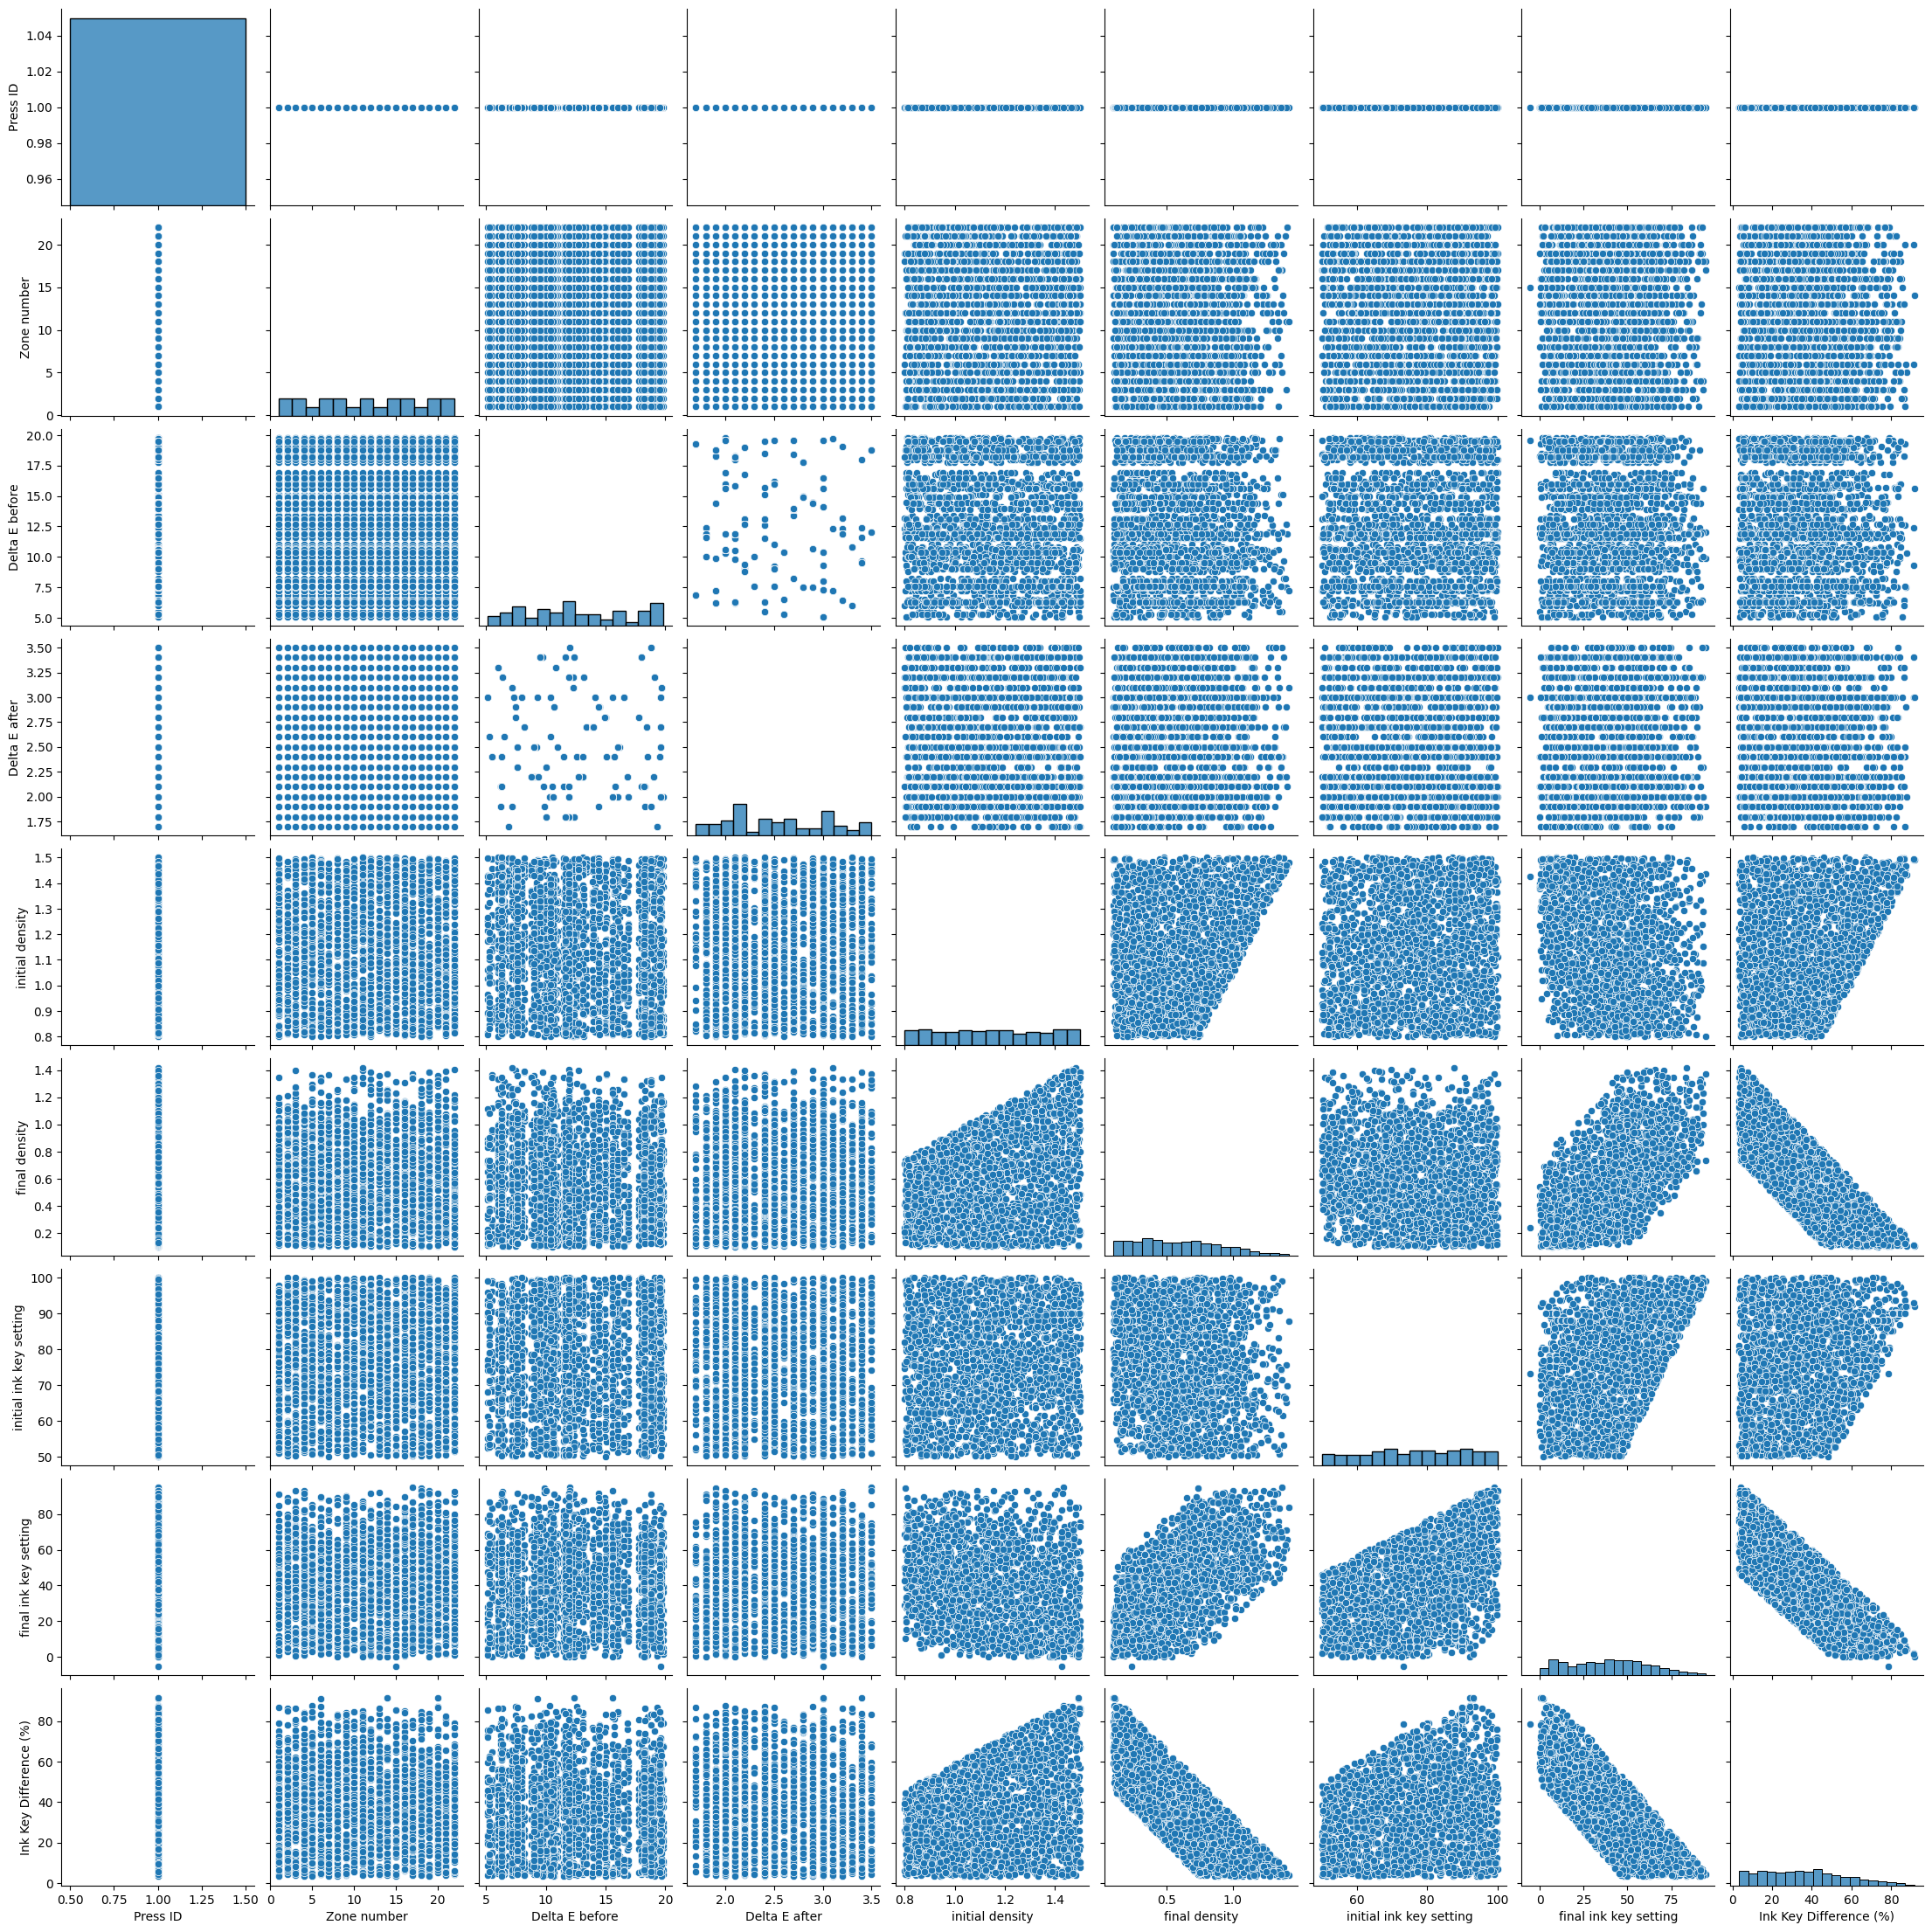

In [3]:
sns.pairplot(df)

In [4]:
df.describe()

,Press ID,Zone number,Delta E before,Delta E after,initial density,final density,initial ink key setting,final ink key setting,Ink Key Difference (%)
count,2200.0,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,1.0,11.500000,12.497000,2.541000,1.147864,0.595672,76.331985,39.887325,36.444660
std,0.0,6.345731,4.343946,0.499131,0.205458,0.312261,14.001508,22.670988,20.610055
min,1.0,1.000000,5.100000,1.700000,0.800000,0.100000,50.010000,-5.394000,3.300000
25%,1.0,6.000000,9.150000,2.100000,0.969000,0.339000,65.109000,21.230750,19.272000
50%,1.0,11.500000,11.950000,2.500000,1.144500,0.569500,77.000000,39.587500,34.980000
75%,1.0,17.000000,16.000000,3.000000,1.329000,0.825000,88.478250,56.416750,50.754000
max,1.0,22.000000,19.800000,3.500000,1.500000,1.420000,99.978000,94.829000,91.740000


In [5]:
df['Ink key zero setting'] = df['Ink key zero setting'].str.replace("mm","",regex=False).astype(int)

In [6]:
df.dtypes

Press ID                     int64
Paper type                     str
Zone number                  int64
Color                          str
Ink key zero setting         int64
Delta E before             float64
Delta E after              float64
initial density            float64
final density              float64
initial ink key setting    float64
final ink key setting      float64
Ink Key Difference (%)     float64
dtype: object

In [7]:
df = pd.get_dummies(df, columns=['Paper type', 'Color'], dtype=int)

In [8]:
df.dtypes

Press ID                     int64
Zone number                  int64
Ink key zero setting         int64
Delta E before             float64
Delta E after              float64
initial density            float64
final density              float64
initial ink key setting    float64
final ink key setting      float64
Ink Key Difference (%)     float64
Paper type_Coated            int64
Paper type_Uncoated          int64
Color_Black                  int64
Color_Cyan                   int64
Color_Magenta                int64
Color_Yellow                 int64
dtype: object

In [9]:
df

,Press ID,Zone number,Ink key zero setting,Delta E before,Delta E after,initial density,final density,initial ink key setting,final ink key setting,Ink Key Difference (%),Paper type_Coated,Paper type_Uncoated,Color_Black,Color_Cyan,Color_Magenta,Color_Yellow
0,1,1,0,19.8,2.0,0.879,0.729,90.440,80.540,9.900,0,1,0,1,0,0
1,1,2,0,19.8,2.0,1.128,0.484,81.000,38.496,42.504,0,1,0,1,0,0
2,1,3,0,19.8,2.0,1.467,0.270,80.550,1.548,79.002,0,1,0,1,0,0
3,1,4,0,19.8,2.0,0.962,0.186,66.025,14.809,51.216,0,1,0,1,0,0
4,1,5,0,19.8,2.0,0.867,0.465,88.928,62.396,26.532,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,1,18,0,11.9,2.0,1.466,0.243,90.000,9.282,80.718,0,1,1,0,0,0
2196,1,19,0,11.9,2.0,1.204,0.454,65.112,15.612,49.500,0,1,1,0,0,0
2197,1,20,0,11.9,2.0,0.906,0.761,94.148,84.578,9.570,0,1,1,0,0,0
2198,1,21,0,11.9,2.0,0.998,0.128,95.365,37.945,57.420,0,1,1,0,0,0


In [10]:
x=df.drop('final ink key setting',axis=1)
y=df['final ink key setting']
x

,Press ID,Zone number,Ink key zero setting,Delta E before,Delta E after,initial density,final density,initial ink key setting,Ink Key Difference (%),Paper type_Coated,Paper type_Uncoated,Color_Black,Color_Cyan,Color_Magenta,Color_Yellow
0,1,1,0,19.8,2.0,0.879,0.729,90.440,9.900,0,1,0,1,0,0
1,1,2,0,19.8,2.0,1.128,0.484,81.000,42.504,0,1,0,1,0,0
2,1,3,0,19.8,2.0,1.467,0.270,80.550,79.002,0,1,0,1,0,0
3,1,4,0,19.8,2.0,0.962,0.186,66.025,51.216,0,1,0,1,0,0
4,1,5,0,19.8,2.0,0.867,0.465,88.928,26.532,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,1,18,0,11.9,2.0,1.466,0.243,90.000,80.718,0,1,1,0,0,0
2196,1,19,0,11.9,2.0,1.204,0.454,65.112,49.500,0,1,1,0,0,0
2197,1,20,0,11.9,2.0,0.906,0.761,94.148,9.570,0,1,1,0,0,0
2198,1,21,0,11.9,2.0,0.998,0.128,95.365,57.420,0,1,1,0,0,0


In [11]:
y

0       80.540
1       38.496
2        1.548
3       14.809
4       62.396
         ...  
2195     9.282
2196    15.612
2197    84.578
2198    37.945
2199    49.166
Name: final ink key setting, Length: 2200, dtype: float64

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# First Model
We will first try to predict using Linear Regression

In [13]:
linear = LinearRegression()

In [14]:
linear.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
linear.score(x_train,y_train)

1.0

In [16]:
y_pred = linear.predict(x_test)

In [17]:
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

print("\n--- Test Set Accuracy ---")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R^2 Score: {test_r2:.4f}")


--- Test Set Accuracy ---
MSE: 0.0000
RMSE: 0.0000
R^2 Score: 1.0000


We can see that he have achieved a R^2 score of 1 and almost zero error. This is working perfectly as we've considered a synthetic dataset with a linear relation

# Second Model
We will try using random forest regressor

In [18]:
rf = RandomForestRegressor().fit(x_train,y_train)

In [19]:
rf.score(x_train,y_train)

0.9997743961290001

In [20]:
y_pred = rf.predict(x_test)

In [21]:
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

print("\n--- Test Set Accuracy ---")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R^2 Score: {test_r2:.4f}")


--- Test Set Accuracy ---
MSE: 0.7672
RMSE: 0.8759
R^2 Score: 0.9984


We will now find the optimum number of regressors using a curve and a list to store the scores

Max score is 0.9985101095478164
Required number of estimators 193


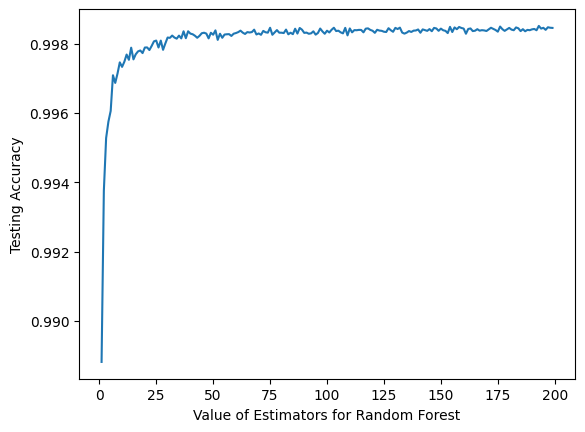

In [22]:
scores = []
for i in range(1,200):
    rf = RandomForestRegressor(n_estimators=i).fit(x_train,y_train)
    scores.append(rf.score(x_test,y_test))
plt.plot(range(1, 200), scores)
plt.xlabel('Value of Estimators for Random Forest')
plt.ylabel('Testing Accuracy')
print('Max score is',max(scores))
print('Required number of estimators',scores.index(max(scores))+1)

## Findings
We have achieved a score of 0.9985 which is good. Unline the linear model, there is a reduction in accuracy, which needs to be seen

## Third Model
We will now use GradientBoostingRegressor

In [23]:
gb = GradientBoostingRegressor().fit(x_train,y_train)

In [24]:
gb.score(x_train,y_train)

0.9978671528852323

In [25]:
y_pred = gb.predict(x_test)

In [26]:
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

print("\n--- Test Set Accuracy ---")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R^2 Score: {test_r2:.4f}")


--- Test Set Accuracy ---
MSE: 1.5588
RMSE: 1.2485
R^2 Score: 0.9968


We will now find the best learning rateusing a curve and a list to store the scores

Text(0, 0.5, 'Testing Accuracy')

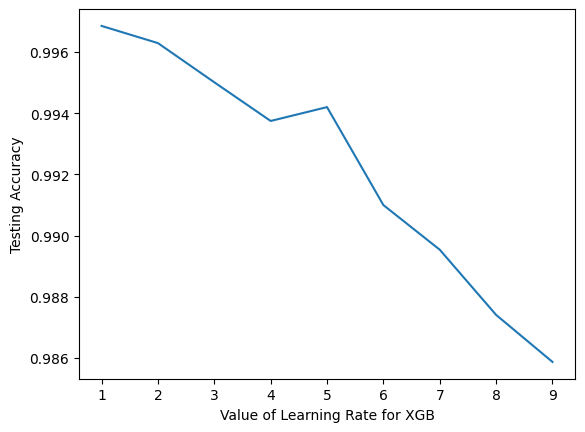

In [27]:

scores = []
for i in range(1,10):
    gb = GradientBoostingRegressor(learning_rate=(i*0.1)).fit(x_train,y_train)
    scores.append(gb.score(x_test,y_test))
plt.plot(range(1, 10), scores)
plt.xlabel('Value of Learning Rate for XGB')
plt.ylabel('Testing Accuracy')

We will now find the optimum number of regressors for the obtained learning rate using a curve and a list to store the scores

Text(0, 0.5, 'Testing Accuracy')

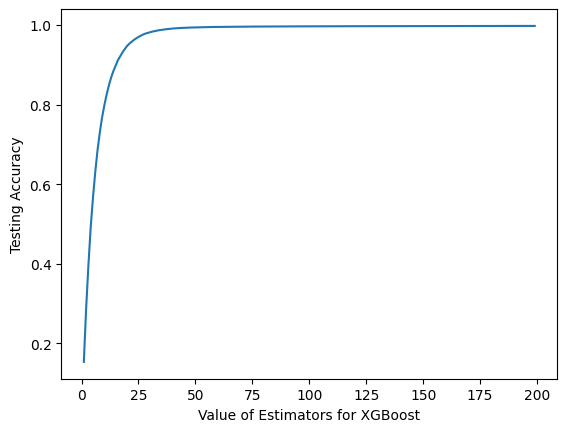

In [28]:
#Changing n_predictors for an optimal learning rate
scores = []
for i in range(1,200):
    gb = GradientBoostingRegressor(learning_rate=0.1,n_estimators=i).fit(x_train,y_train)
    scores.append(gb.score(x_test,y_test))
plt.plot(range(1, 200), scores)
plt.xlabel('Value of Estimators for XGBoost')
plt.ylabel('Testing Accuracy')

In [29]:
print('Max score is',max(scores))
print('Required number of estimators',scores.index(max(scores))+1)

Max score is 0.9979228311075535
Required number of estimators 197


## Fourth model
We will now use ridge cross validation

In [30]:
ridge = RidgeCV(alphas=np.logspace(-3, 3, 7)).fit(x_train,y_train)

In [31]:
ridge.score(x_train,y_train)

0.9999999999999004

In [32]:
y_pred = ridge.predict(x_test)

In [33]:
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

print("\n--- Test Set Accuracy ---")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R^2 Score: {test_r2:.4f}")


--- Test Set Accuracy ---
MSE: 0.0000
RMSE: 0.0000
R^2 Score: 1.0000


## Hybrid approach
A hybrid/stacking approach of multiple models 

In [34]:
estimators = [
    ('lr',LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=170, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=199, learning_rate=0.1, random_state=42)),
    ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 7)))
]


stack = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(),
    cv=5,
    passthrough=True
)
stack.fit(x_train,y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('lr', ...), ('rf', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",RidgeCV()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",True
,"verbose verbose: int, default=0Verbosity level.",0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`.

In [35]:
y_pred = stack.predict(x_test)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

print("\n--- Test Set Accuracy ---")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R^2 Score: {test_r2:.4f}")


--- Test Set Accuracy ---
MSE: 0.0000
RMSE: 0.0000
R^2 Score: 1.0000


We will set parameters for GridSearchCV. We will find the optimized paramters for the stack of classifiers we used above

In [36]:
param_grid = {
    
    'rf__n_estimators': [50, 200],
    'rf__max_depth': [None, 10],
    
    
    'gbr__learning_rate': [0.01, 0.1],
    'gbr__n_estimators': [100, 200],
    
    'final_estimator__alphas': [0.1, 1.0, 10.0]
}

We print the list of best parameters

In [37]:
grid = GridSearchCV(
    estimator=stack, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1 
)

grid.fit(x_train, y_train)

print(f"Best Params: {grid.best_params_}")

Best Params: {'final_estimator__alphas': 0.1, 'gbr__learning_rate': 0.01, 'gbr__n_estimators': 200, 'rf__max_depth': 10, 'rf__n_estimators': 50}


Thus, we can get the best prediction

In [38]:
y_pred = grid.predict(x_test)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

print("\n--- Test Set Accuracy ---")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R^2 Score: {test_r2:.4f}")


--- Test Set Accuracy ---
MSE: 0.0000
RMSE: 0.0000
R^2 Score: 1.0000
